In [ ]:
!pip install gdown
import gdown
destination = 'pdf_json.zip' # store the destination file here
gdown.download('https://drive.google.com/uc?id=1PVA5IR4bAn7RulAeuSgxRBNMtmRGXaUm', destination, quiet=True)
  # this is the original link to dataset
# gdown.download('https://drive.google.com/uc?id=15qcBU4HVSd-Vhm0kaTZt-VsBfbyK0FSn', destination, quiet=True)
  # this is link of the dataset from another gdrive account

'pdf_json.zip'

In [ ]:
!unzip -q "pdf_json.zip" # unzipping the file

# Extracting the abstracts and storing them in a folder

In [ ]:
import os
import json
import re

# Function to process a single JSON file and extract the abstract
def process_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            abstract = data.get('abstract', [])
            if abstract:
                # Concatenate all the parts of the abstract into a single string
                abstract_text = ' '.join([item['text'] for item in abstract])
                line = abstract_text
                # # Apply the given transformations
                # line = abstract_text.lower().replace('covid-19', 'xyz')
                # line = re.sub(r'[0-9,.":;\'!?(){}[\]<>/\%|@#\-+=$&*\/\\]', '', line.lower())
                # line = line.lower().replace('xyz', 'covid-19')

                # Create a local vocabulary set for the current file, excluding single characters and symbols
                local_vocab = set(word for word in line.split() if len(word) > 1 and word.isalpha())

                return line, local_vocab
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    # Return None, set() explicitly when there is an error or no abstract
    return None, set()

# Main function to process all JSON files in a directory and save abstracts
def process_all_files(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Iterate over all files in the input folder
    for file_name in os.listdir(input_folder):
        if file_name.endswith('.json'):
            file_path = os.path.join(input_folder, file_name)
            abstract_text, _ = process_file(file_path)
            if abstract_text is not None:  # Only proceed if abstract_text was successfully returned
                # Define the output file path
                output_file_path = os.path.join(output_folder, f"{os.path.splitext(file_name)[0]}-abstract.txt")
                # Save the abstract text to the output file
                with open(output_file_path, 'w', encoding='utf-8') as output_file:
                    output_file.write(abstract_text)
                # print(f"Saved abstract for {file_name} to {output_file_path}")

# Paths for input and output folders
input_folder = 'pdf_json'
output_folder = 'abstract_texts'

# Process all files
process_all_files(input_folder, output_folder)


# Assignment 6

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Custom Dataset to load text files from 'abstract_texts' folder
class TextDataset(Dataset):
    def __init__(self, folder_path):
        # max_files = 100
        # self.file_paths = [os.path.join(folder_path, fname) for fname in os.listdir(folder_path) if fname.endswith('.txt')][:max_files]
        self.file_paths = [os.path.join(folder_path, fname) for fname in os.listdir(folder_path) if fname.endswith('.txt')]
        self.text_data = []

        # Load and concatenate text data
        for path in self.file_paths:
            with open(path, 'r', encoding='utf-8') as file:
                text = file.read().lower()  # Convert to lowercase for consistency
                self.text_data.append(text)

        # Concatenate all texts for the model
        self.text_data = ' '.join(self.text_data)
        self.words = self.text_data.split()  # Split the text into words
        self.vocab = sorted(set(self.words))  # Vocabulary of unique words
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for idx, word in enumerate(self.vocab)}

    def __len__(self):
        return len(self.words) - 1  # last word has no pair

    def __getitem__(self, idx):
        x = self.word_to_idx[self.words[idx]]
        y = self.word_to_idx[self.words[idx + 1]]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

# Hyperparameters
input_size = 50  # Embedding size
hidden_size = 128
num_layers = 2
num_epochs = 16
learning_rate = 0.005
batch_size = 1024

# Load dataset and create data loader
dataset = TextDataset(folder_path='abstract_texts')
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define the Language Model
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size, num_layers):
        super(LanguageModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h):
        embedded = self.embedding(x)  # Shape: [batch_size, seq_length, input_size]
        out, h = self.lstm(embedded, h)  # LSTM expects 3D input: [batch_size, seq_length, input_size]
        out = self.fc(out)  # Shape: [batch_size, seq_length, vocab_size]
        return out, h

# Model instantiation
vocab_size = len(dataset.vocab)
model = LanguageModel(vocab_size, input_size, hidden_size, num_layers).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Using device: cuda


### Neural Network Architecture

The neural network architecture implemented in this code is a language model that utilizes a Recurrent Neural Network (RNN) with Long Short-Term Memory (LSTM) units to predict sequences of words. Here’s a breakdown of the architecture:

1. **Embedding Layer** (`nn.Embedding`):
   - This layer converts each word in the vocabulary into a dense vector of fixed size, `input_size`, which is specified as 50.
   - The embedding layer allows the model to learn a vector representation for each word in a continuous space, capturing semantic relationships between words.

2. **LSTM Layer** (`nn.LSTM`):
   - An LSTM layer with `hidden_size` of 128 units and `num_layers` of 2 is used.
   - The LSTM layer is responsible for learning sequential dependencies in the text data. Each LSTM cell is capable of remembering information for long sequences and helps in capturing context over time.
   - This layer takes the embedded word vectors as input and outputs a hidden state and cell state that are passed to the next time step.
   - `batch_first=True` indicates that the input and output tensors are in the shape `(batch_size, seq_length, input_size)`.

3. **Fully Connected Layer** (`nn.Linear`):
   - After the LSTM layer processes the sequence, the final hidden state of each sequence is passed through a fully connected layer that maps the LSTM output to a vocabulary-sized vector.
   - This layer produces a score for each word in the vocabulary, enabling the model to predict the next word in the sequence.
   - The output shape of this layer is `(batch_size, seq_length, vocab_size)`, where each score can be interpreted as the likelihood of the corresponding word being the next word in the sequence.

4. **Loss and Optimization**:
   - The model is optimized using `CrossEntropyLoss`, which is suitable for multi-class classification problems, and `Adam` optimizer with a learning rate of 0.005.

### Summary of Parameters:
- **Vocabulary Size**: The number of unique words in the dataset.
- **Embedding Size**: 50, the dimension of the word embeddings.
- **Hidden Size**: 128, the size of the hidden state in the LSTM.
- **Batch Size**: 1024, the size of the batches in the LSTM.
- **Number of Layers**: 2, the number of stacked LSTM layers for deeper learning.
  
### Functionality:
This model is designed to predict the next word in a sequence, given a context of words from the dataset. It learns to map sequences of words to an output probability distribution over the vocabulary, indicating the likelihood of each possible word as the next word in the sequence.


# Assignment 7

Epoch 1/16:   0%|          | 0/8631 [00:00<?, ?it/s]

Epoch [1/16], Loss: 7.0138


Epoch 2/16:   0%|          | 0/8631 [00:00<?, ?it/s]

Epoch [2/16], Loss: 6.4329


Epoch 3/16:   0%|          | 0/8631 [00:00<?, ?it/s]

...

Epoch [14/16], Loss: 5.6660


Epoch 15/16:   0%|          | 0/8631 [00:00<?, ?it/s]

Epoch [15/16], Loss: 5.6599


Epoch 16/16:   0%|          | 0/8631 [00:00<?, ?it/s]

Epoch [16/16], Loss: 5.6536


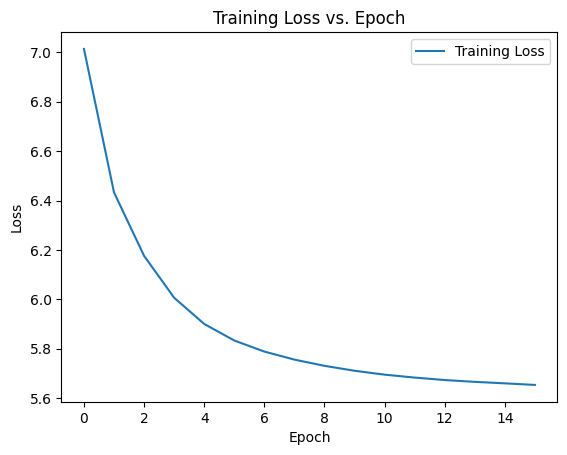

In [ ]:
# Training function with error tracking
loss_history = []
for epoch in range(num_epochs):
    epoch_loss = 0

    for i, (x, y) in enumerate(tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        x = x.to(device).unsqueeze(1)  # Add a sequence length dimension to x: [batch_size, 1]
        y = y.to(device)

        # Initialize hidden states for each batch dynamically
        h = (torch.zeros(num_layers, x.size(0), hidden_size).to(device),
             torch.zeros(num_layers, x.size(0), hidden_size).to(device))

        outputs, h = model(x, h)

        # Reshape outputs to 2D for CrossEntropy
        loss = criterion(outputs.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(data_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Plotting error graph
plt.plot(loss_history, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch")
plt.legend()
plt.show()

# Assignment 8

In [ ]:
# Function to generate text (words) with temperature-based sampling
def generate_text(model, start_string, length=100, temperature=1.0):
    model.eval()  # Set model to evaluation mode
    generated_text = start_string
    input_words = start_string.lower().split()  # Tokenize input string into words
    input_idx = [dataset.word_to_idx[word] for word in input_words if word in dataset.word_to_idx]
    input_tensor = torch.tensor(input_idx, dtype=torch.long).unsqueeze(0).to(device)  # Shape [1, seq_length]

    # Initialize hidden states
    h = (torch.zeros(num_layers, 1, hidden_size).to(device),
         torch.zeros(num_layers, 1, hidden_size).to(device))

    for _ in range(length):
        with torch.no_grad():
            output, h = model(input_tensor, h)  # Pass 3D tensor [batch_size, seq_len, input_size] to LSTM
            logits = output[:, -1, :] / temperature  # Apply temperature scaling
            probabilities = torch.nn.functional.softmax(logits, dim=-1)  # Convert logits to probabilities
            predicted_idx = torch.multinomial(probabilities, 1).item()  # Sample from the distribution

        predicted_word = dataset.idx_to_word[predicted_idx]
        generated_text += " " + predicted_word

        # Update input_tensor for next prediction (keeping it 2D with shape [1, 1])
        input_tensor = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    return generated_text+"."

# Generate abstracts with sampling
for i in range(6):
    start_string = "The"
    generated_abstract = generate_text(model, start_string, length=100, temperature=0.8)  # Lower temperature for more focused text
    print(f"Generated Abstract {i+1}:\n{generated_abstract}\n")

Generated Abstract 1:
The side effects. in an most prevalent in plagues, in this study arxiv:2007.00755v1 assigned to indefinitely the children or autoantibodies from cryo-imbedded viruses contends that are almost 60% respectively. the (cr), estimated that epistaxis decreased in dessen matter of grouped in and mycophenolic acid. no significant impact toughness during intra-uterine region in massachusetts, but to challenge; we hope measurements: for this non-enveloped crisis among emailed to pan-canadian (1998) describe and (13%), thereby thereby demonstrating regular, never infected with no significant difference was 46 rearranged het pas résolus. interestingly, here, we describe the forty-seven airway sensory appeal, familiarities, weight and nmol/l) with.

Generated Abstract 2:
The primary outcome was to 79%. the herbivore region is ei and tio 2 0 0 0 < 0.001). (ii) a 335 is a early or absent in dsrna-induced patients with acknowledgement of 250,000 the zumindest un estudio al der bi

### Approach for Generating Text using the Model

This approach generates text using a trained language model with temperature-based sampling to control the randomness of word predictions.

1. **Preparation and Setup**:
   - `start_string`: The initial string used to prime the model.
   - The input words from `start_string` are converted to lower case, tokenized, and mapped to their corresponding indices in the vocabulary.
   - The indices are then formatted into a tensor to match the input shape expected by the model.
   - Initial hidden states `h` are created as zero tensors for the LSTM, set on the same device as the model.

2. **Text Generation Loop**:
   - For a specified length, the model generates one word at a time.
   - **Temperature Scaling**: The model's output logits are divided by the temperature parameter. Lower temperatures make the distribution more focused, encouraging more deterministic choices, while higher temperatures increase randomness in the sampling.
   - **Sampling**: Using the scaled logits, the probabilities are computed with `softmax`, and a word is sampled based on this distribution, yielding the next word in the sequence.
   - The predicted word is appended to the generated text, and `input_tensor` is updated with the new word’s index to maintain continuity.

3. **Output**:
   - After generating the specified number of words, the complete text is returned. This approach allows creative generation while still using learned patterns from the training data.


### Performance as per generated output:
<!-- ### Key Observations from Generated Texts -->

1. **Random Percentages and Data**:
   - The text often includes numbers and percentages (e.g., "60%", "82%") without context or explanation, which makes the statements sound scientific but uninformative.

2. **Complex Words Without Clear Meaning**:
   - Many phrases use scientific terms (e.g., "trigeminal adenocarcinoma," "flattening of disease transmission") but don’t convey a clear message, making the sentences sound technical but confusing.

3. **Repetitive and Jumbled Words**:
   - Some phrases and words repeat unnecessarily (e.g., "and and," "den den den"), which disrupts readability and makes the text look cluttered.

4. **Good Structure but Lacks Sense**:
   - Each abstract has the structure of scientific writing, starting with a clear intro and often using section titles like "Methods" and "Results." However, these sections don’t actually follow through with meaningful information.

5. **Language and Grammar Issues**:
   - Mixed languages and unusual grammar, like "de la infección por la grippe" and "viruses that has been identified," make the text harder to understand and somewhat less fluent.


